# Per Cell Type DEG Overlap Analysis
## Cirrhosis vs Hepatitis (NT vs TC)
- padj < 0.05, |log2FC| >= 0.5 기준
- 각 셀타입별 Up/Down Venn Diagram

In [96]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import warnings
warnings.filterwarnings('ignore')

out_dir = 'results_output'
save_dir = os.path.join(out_dir, 'overlap_genes')
os.makedirs(save_dir, exist_ok=True)

## Hepatocytes

In [97]:
# Hepatocytes 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Hepatocyte.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Hepatocyte.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

# 유의한 DEG 필터링: padj < 0.05 & |log2FC| >= 0.5
cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1100
Hepatitis total DEGs: 1057
Cirrhosis significant: 861 (Up: 286, Down: 575)
Hepatitis significant: 313 (Up: 139, Down: 174)


In [136]:
76+63

139

In [135]:
63+223

286

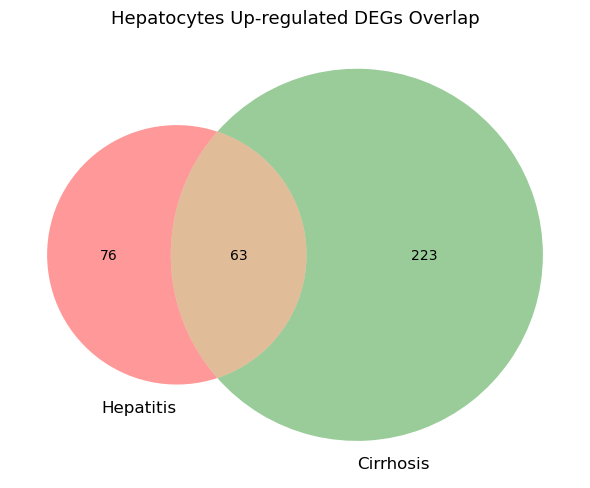

Up-regulated 교집합: 63
Hepatitis only Up: 76
Cirrhosis only Up: 223


In [98]:
# Hepatocytes Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Hepatocytes Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

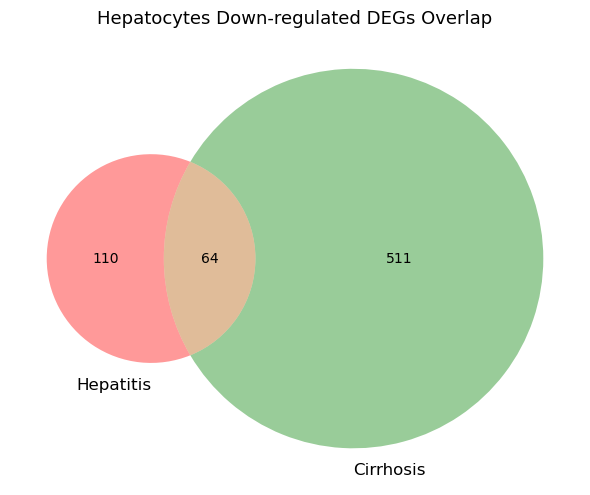

Down-regulated 교집합: 64
Hepatitis only Down: 110
Cirrhosis only Down: 511


In [99]:
# Hepatocytes Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Hepatocytes Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [100]:
# Hepatocytes overlap 유전자 저장
ct = 'Hepatocyte'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Hepatocyte overlap genes saved:
  Cirrhosis only Up: 223
  Hepatitis only Up: 76
  Cirrhosis only Down: 511
  Hepatitis only Down: 110


## T_Cells

In [101]:
# T_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Tcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Tcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1062
Hepatitis total DEGs: 920
Cirrhosis significant: 796 (Up: 463, Down: 333)
Hepatitis significant: 346 (Up: 253, Down: 93)


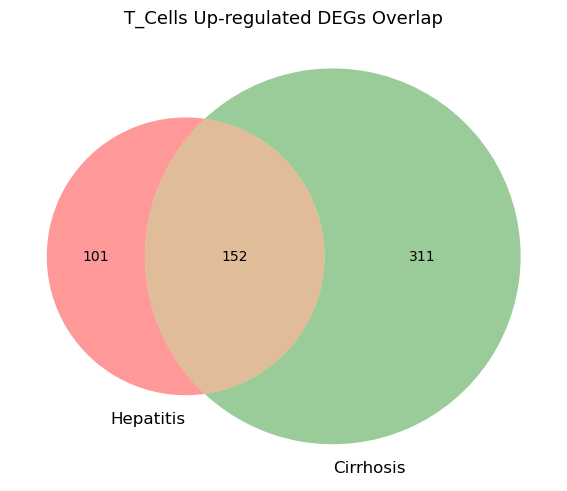

Up-regulated 교집합: 152
Hepatitis only Up: 101
Cirrhosis only Up: 311


In [102]:
# T_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('T_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

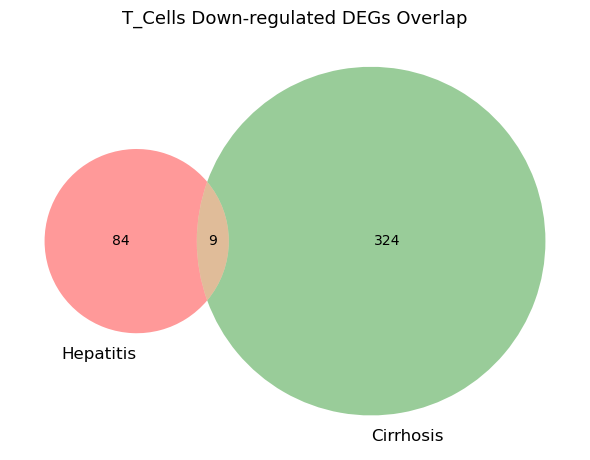

Down-regulated 교집합: 9
Hepatitis only Down: 84
Cirrhosis only Down: 324


In [103]:
# T_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('T_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [104]:
# T_Cells overlap 유전자 저장
ct = 'Tcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Tcell overlap genes saved:
  Cirrhosis only Up: 311
  Hepatitis only Up: 101
  Cirrhosis only Down: 324
  Hepatitis only Down: 84


## Mesenchymal

In [105]:
# Mesenchymal 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Mesenchymal.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Mesenchymal.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1064
Hepatitis total DEGs: 1069
Cirrhosis significant: 765 (Up: 367, Down: 398)
Hepatitis significant: 598 (Up: 447, Down: 151)


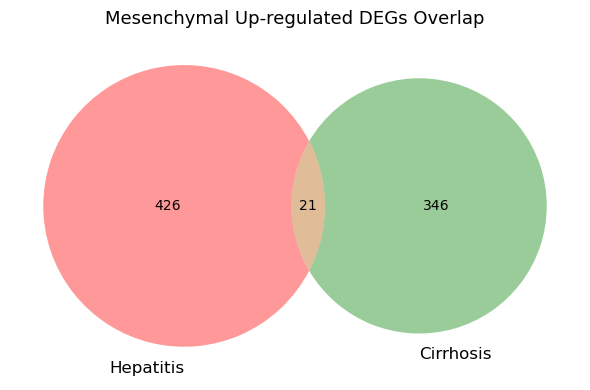

Up-regulated 교집합: 21
Hepatitis only Up: 426
Cirrhosis only Up: 346


In [106]:
# Mesenchymal Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Mesenchymal Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

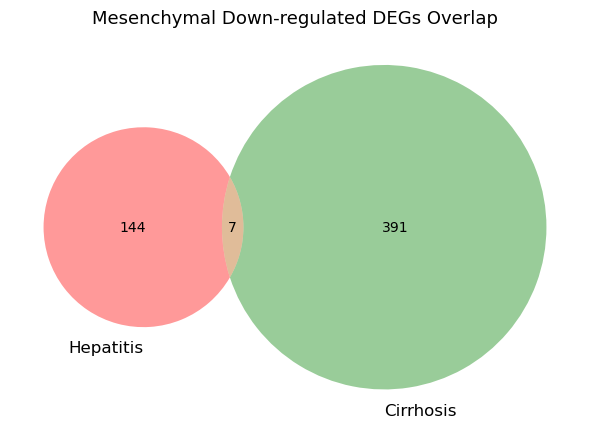

Down-regulated 교집합: 7
Hepatitis only Down: 144
Cirrhosis only Down: 391


In [107]:
# Mesenchymal Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Mesenchymal Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [108]:
# Mesenchymal overlap 유전자 저장
ct = 'Mesenchymal'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Mesenchymal overlap genes saved:
  Cirrhosis only Up: 346
  Hepatitis only Up: 426
  Cirrhosis only Down: 391
  Hepatitis only Down: 144


## Macrophages

In [109]:
# Macrophages 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Macrophage.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Macrophage.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 895
Hepatitis total DEGs: 908
Cirrhosis significant: 423 (Up: 279, Down: 144)
Hepatitis significant: 327 (Up: 206, Down: 121)


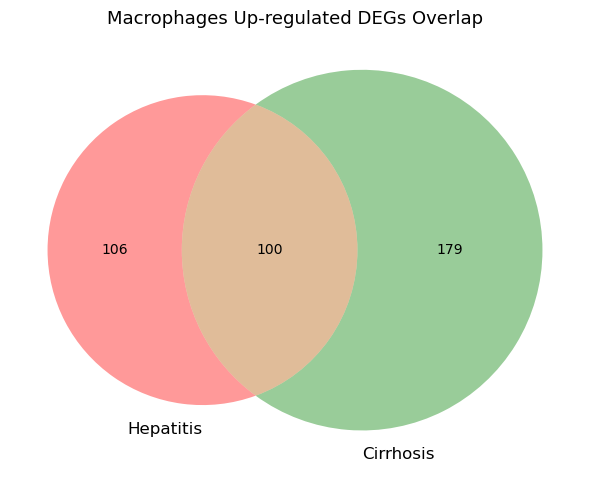

Up-regulated 교집합: 100
Hepatitis only Up: 106
Cirrhosis only Up: 179


In [110]:
# Macrophages Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Macrophages Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

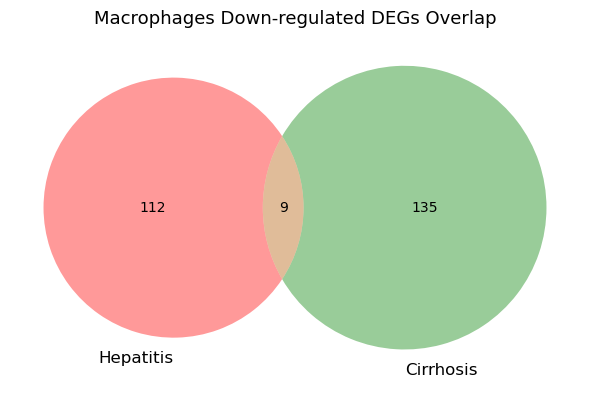

Down-regulated 교집합: 9
Hepatitis only Down: 112
Cirrhosis only Down: 135


In [111]:
# Macrophages Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Macrophages Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [112]:
# Macrophages overlap 유전자 저장
ct = 'Macrophage'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Macrophage overlap genes saved:
  Cirrhosis only Up: 179
  Hepatitis only Up: 106
  Cirrhosis only Down: 135
  Hepatitis only Down: 112


## NK_Cells

In [113]:
# NK_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_NKcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_NKcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 931
Hepatitis total DEGs: 717
Cirrhosis significant: 425 (Up: 291, Down: 134)
Hepatitis significant: 305 (Up: 207, Down: 98)


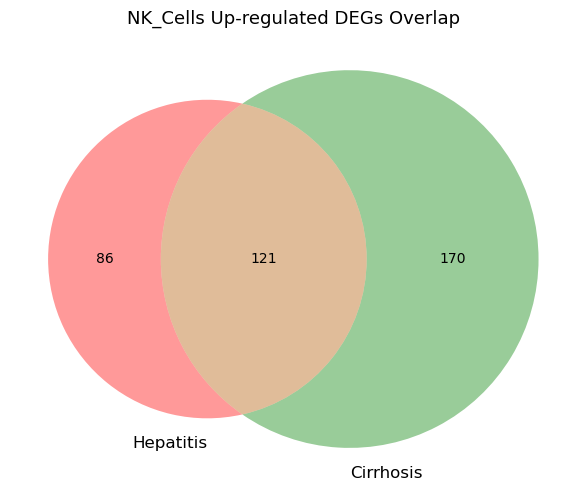

Up-regulated 교집합: 121
Hepatitis only Up: 86
Cirrhosis only Up: 170


In [114]:
# NK_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('NK_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

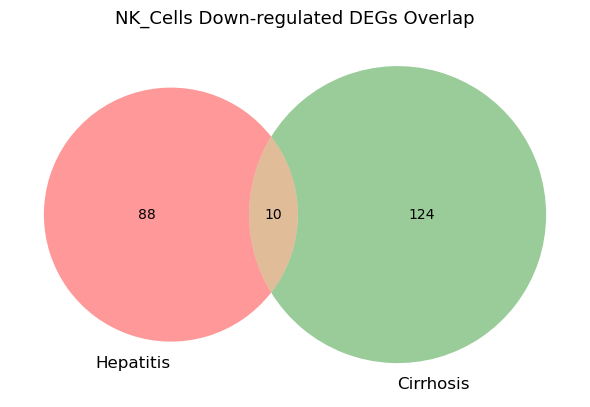

Down-regulated 교집합: 10
Hepatitis only Down: 88
Cirrhosis only Down: 124


In [115]:
# NK_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('NK_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [116]:
# NK_Cells overlap 유전자 저장
ct = 'NKcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

NKcell overlap genes saved:
  Cirrhosis only Up: 170
  Hepatitis only Up: 86
  Cirrhosis only Down: 124
  Hepatitis only Down: 88


## Endothelial_Cells

In [117]:
# Endothelial_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Endothelial.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Endothelial.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1204
Hepatitis total DEGs: 1097
Cirrhosis significant: 975 (Up: 439, Down: 536)
Hepatitis significant: 52 (Up: 2, Down: 50)


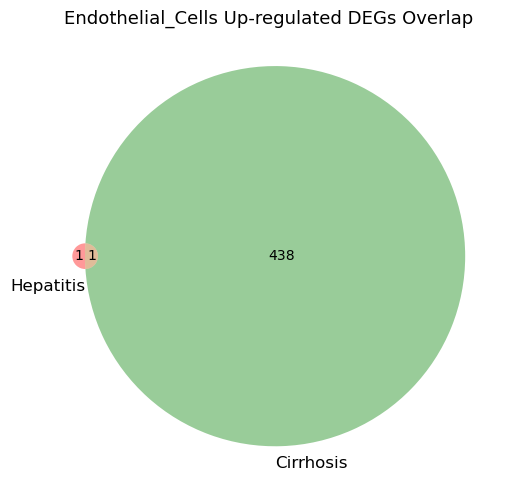

Up-regulated 교집합: 1
Hepatitis only Up: 1
Cirrhosis only Up: 438


In [118]:
# Endothelial_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Endothelial_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

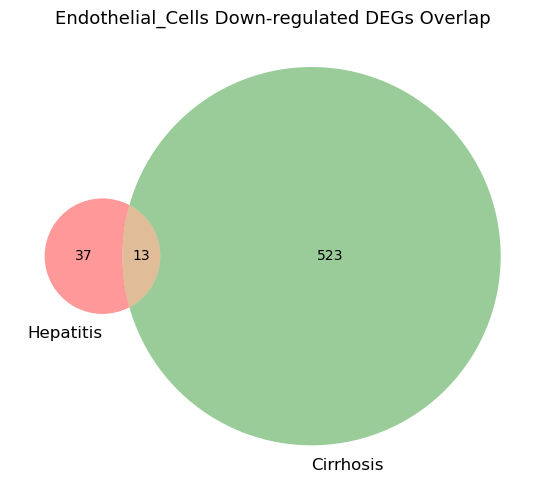

Down-regulated 교집합: 13
Hepatitis only Down: 37
Cirrhosis only Down: 523


In [119]:
# Endothelial_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Endothelial_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [120]:
# Endothelial_Cells overlap 유전자 저장
ct = 'Endothelial'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Endothelial overlap genes saved:
  Cirrhosis only Up: 438
  Hepatitis only Up: 1
  Cirrhosis only Down: 523
  Hepatitis only Down: 37


## Plasma_Cells

In [121]:
# Plasma_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Plasmacell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Plasmacell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1068
Hepatitis total DEGs: 969
Cirrhosis significant: 149 (Up: 127, Down: 22)
Hepatitis significant: 92 (Up: 61, Down: 31)


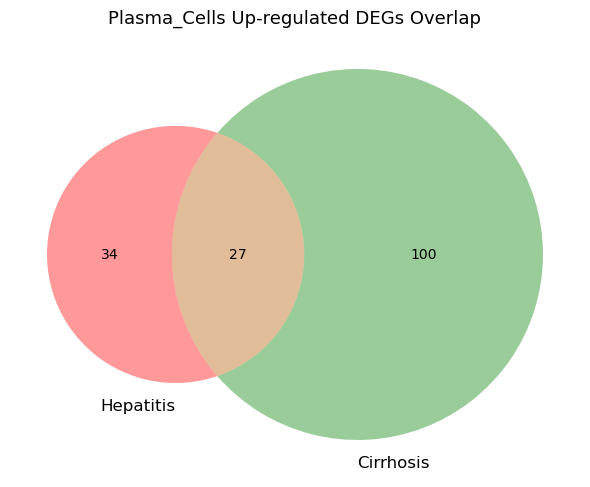

Up-regulated 교집합: 27
Hepatitis only Up: 34
Cirrhosis only Up: 100


In [122]:
# Plasma_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Plasma_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

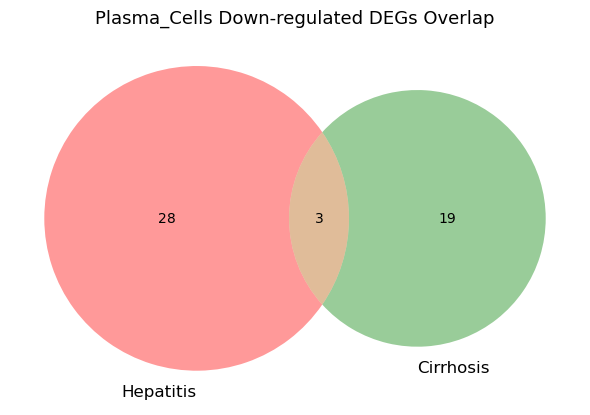

Down-regulated 교집합: 3
Hepatitis only Down: 28
Cirrhosis only Down: 19


In [123]:
# Plasma_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('Plasma_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [124]:
# Plasma_Cells overlap 유전자 저장
ct = 'Plasmacell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Plasmacell overlap genes saved:
  Cirrhosis only Up: 100
  Hepatitis only Up: 34
  Cirrhosis only Down: 19
  Hepatitis only Down: 28


## DCs

In [125]:
# DCs 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_DC.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_DC.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 953
Hepatitis total DEGs: 982
Cirrhosis significant: 87 (Up: 70, Down: 17)
Hepatitis significant: 92 (Up: 63, Down: 29)


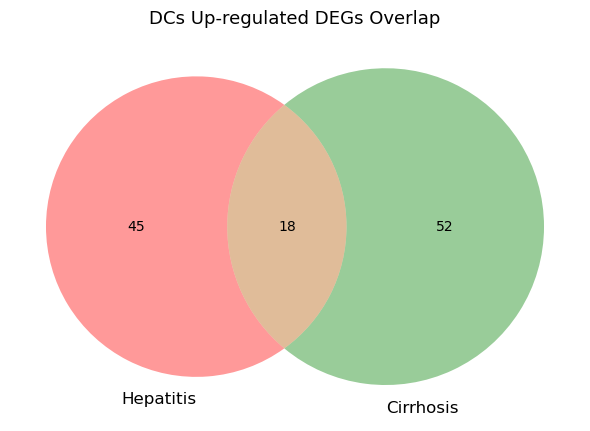

Up-regulated 교집합: 18
Hepatitis only Up: 45
Cirrhosis only Up: 52


In [126]:
# DCs Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('DCs Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

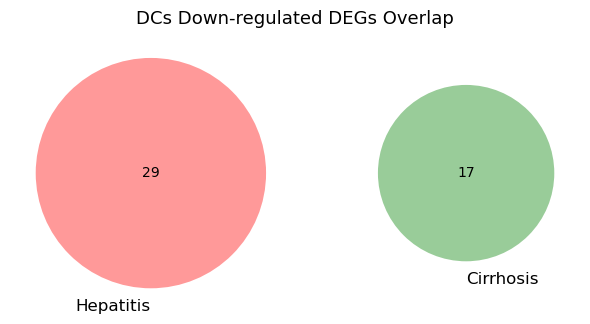

Down-regulated 교집합: 0
Hepatitis only Down: 29
Cirrhosis only Down: 17


In [127]:
# DCs Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('DCs Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [128]:
# DCs overlap 유전자 저장
ct = 'DC'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

DC overlap genes saved:
  Cirrhosis only Up: 52
  Hepatitis only Up: 45
  Cirrhosis only Down: 17
  Hepatitis only Down: 29


## B_Cells

In [129]:
# B_Cells 데이터 로드
cir = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Bcell.csv'))
hep = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Hepatitis_NTvsTC_Bcell.csv'))

print(f'Cirrhosis total DEGs: {len(cir)}')
print(f'Hepatitis total DEGs: {len(hep)}')

cir_sig = cir[(cir['padj'] < 0.05) & (cir['log2FC'].abs() >= 0.5)].copy()
hep_sig = hep[(hep['padj'] < 0.05) & (hep['log2FC'].abs() >= 0.5)].copy()

cir_up = set(cir_sig[cir_sig['log2FC'] > 0]['gene'])
cir_down = set(cir_sig[cir_sig['log2FC'] < 0]['gene'])
hep_up = set(hep_sig[hep_sig['log2FC'] > 0]['gene'])
hep_down = set(hep_sig[hep_sig['log2FC'] < 0]['gene'])

print(f'Cirrhosis significant: {len(cir_sig)} (Up: {len(cir_up)}, Down: {len(cir_down)})')
print(f'Hepatitis significant: {len(hep_sig)} (Up: {len(hep_up)}, Down: {len(hep_down)})')

Cirrhosis total DEGs: 1062
Hepatitis total DEGs: 1021
Cirrhosis significant: 38 (Up: 35, Down: 3)
Hepatitis significant: 16 (Up: 16, Down: 0)


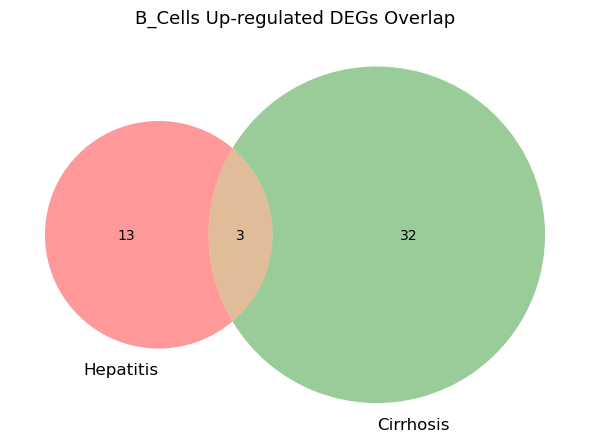

Up-regulated 교집합: 3
Hepatitis only Up: 13
Cirrhosis only Up: 32


In [130]:
# B_Cells Up-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_up, cir_up], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('B_Cells Up-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_up = cir_up & hep_up
print(f'Up-regulated 교집합: {len(overlap_up)}')
print(f'Hepatitis only Up: {len(hep_up - cir_up)}')
print(f'Cirrhosis only Up: {len(cir_up - hep_up)}')

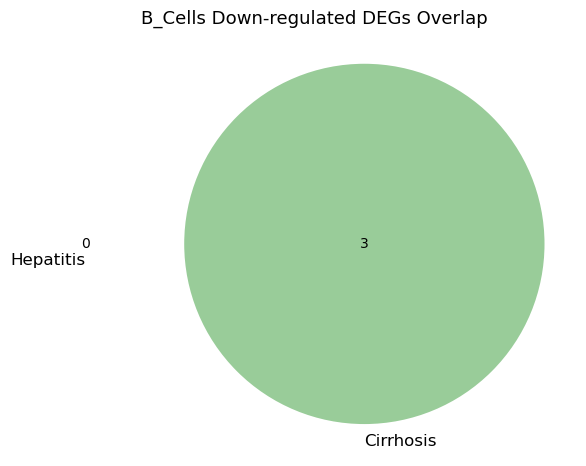

Down-regulated 교집합: 0
Hepatitis only Down: 0
Cirrhosis only Down: 3


In [131]:
# B_Cells Down-regulated Venn Diagram
fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([hep_down, cir_down], set_labels=('Hepatitis', 'Cirrhosis'), ax=ax)
ax.set_title('B_Cells Down-regulated DEGs Overlap', fontsize=13)
plt.tight_layout()
plt.show()

overlap_down = cir_down & hep_down
print(f'Down-regulated 교집합: {len(overlap_down)}')
print(f'Hepatitis only Down: {len(hep_down - cir_down)}')
print(f'Cirrhosis only Down: {len(cir_down - hep_down)}')

In [132]:
# B_Cells overlap 유전자 저장
ct = 'Bcell'

cir_only_up = sorted(cir_up - hep_up)
hep_only_up = sorted(hep_up - cir_up)
cir_only_down = sorted(cir_down - hep_down)
hep_only_down = sorted(hep_down - cir_down)

for genes, label in [(cir_only_up, 'Cirrhosis_only_Up'), (hep_only_up, 'Hepatitis_only_Up'),
                      (cir_only_down, 'Cirrhosis_only_Down'), (hep_only_down, 'Hepatitis_only_Down')]:
    with open(os.path.join(save_dir, f'overlap_{ct}_{label}_{len(genes)}genes.txt'), 'w') as f:
        f.write('\n'.join(genes))

print(f'{ct} overlap genes saved:')
print(f'  Cirrhosis only Up: {len(cir_only_up)}')
print(f'  Hepatitis only Up: {len(hep_only_up)}')
print(f'  Cirrhosis only Down: {len(cir_only_down)}')
print(f'  Hepatitis only Down: {len(hep_only_down)}')

Bcell overlap genes saved:
  Cirrhosis only Up: 32
  Hepatitis only Up: 13
  Cirrhosis only Down: 3
  Hepatitis only Down: 0
